In [1]:
import os
import numpy as np
import pandas as pd
import plotnine as pln

In [ ]:
cutoffs = np.arange(0.1, 1.1, 0.1)

res_dict = {'Source':[], 'Dataset':[], 'Treshold':[], 'Fraction':[]}
for source in ['cellular', 'viral']:
    dir_path = f'../data/{source}/metadata/'
    for file in os.listdir(dir_path):
        for cutoff in cutoffs:
            data = pd.read_csv(f'../data/{source}/metadata/{file}')
            data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
            
            grouped_data = data.groupby('site', as_index=False, observed=True)['target'].std()#.fillna(0)
            
            global_std = data['target'].std()
            grouped_data['frac_std'] = grouped_data['target'] / global_std
            sites = list(grouped_data.query(f'frac_std > {cutoff}')['site'].values)
            data = data.query('site in @sites')
            fraction = len(sites)/grouped_data.shape[0] # frac=part/total

            res_dict['Source'].append(source)
            res_dict['Dataset'].append(file.replace('.csv', ''))
            res_dict['Fraction'].append(fraction)
            res_dict['Treshold'].append(cutoff)

FHVS = pd.DataFrame.from_dict(res_dict)
FHVS['Source'] = pd.Categorical(FHVS['Source'], categories=['viral', 'cellular'])
FHVS['Treshold'] = FHVS['Treshold'].round(1)
FHVS

In [4]:
FHVS = pd.read_csv('../experiments/FHVS/FHVS_multiple_thresholds.csv', index_col=0)
FHVS

,Source,Dataset,Treshold,Fraction
0,cellular,TIM_THETH,0.1,0.975000
1,cellular,TIM_THETH,0.2,0.900000
2,cellular,TIM_THETH,0.3,0.837500
3,cellular,TIM_THETH,0.4,0.775000
4,cellular,TIM_THETH,0.5,0.725000
...,...,...,...,...
735,viral,SARS2_RBD_expression_Starr,0.6,0.338308
736,viral,SARS2_RBD_expression_Starr,0.7,0.194030
737,viral,SARS2_RBD_expression_Starr,0.8,0.104478
738,viral,SARS2_RBD_expression_Starr,0.9,0.049751


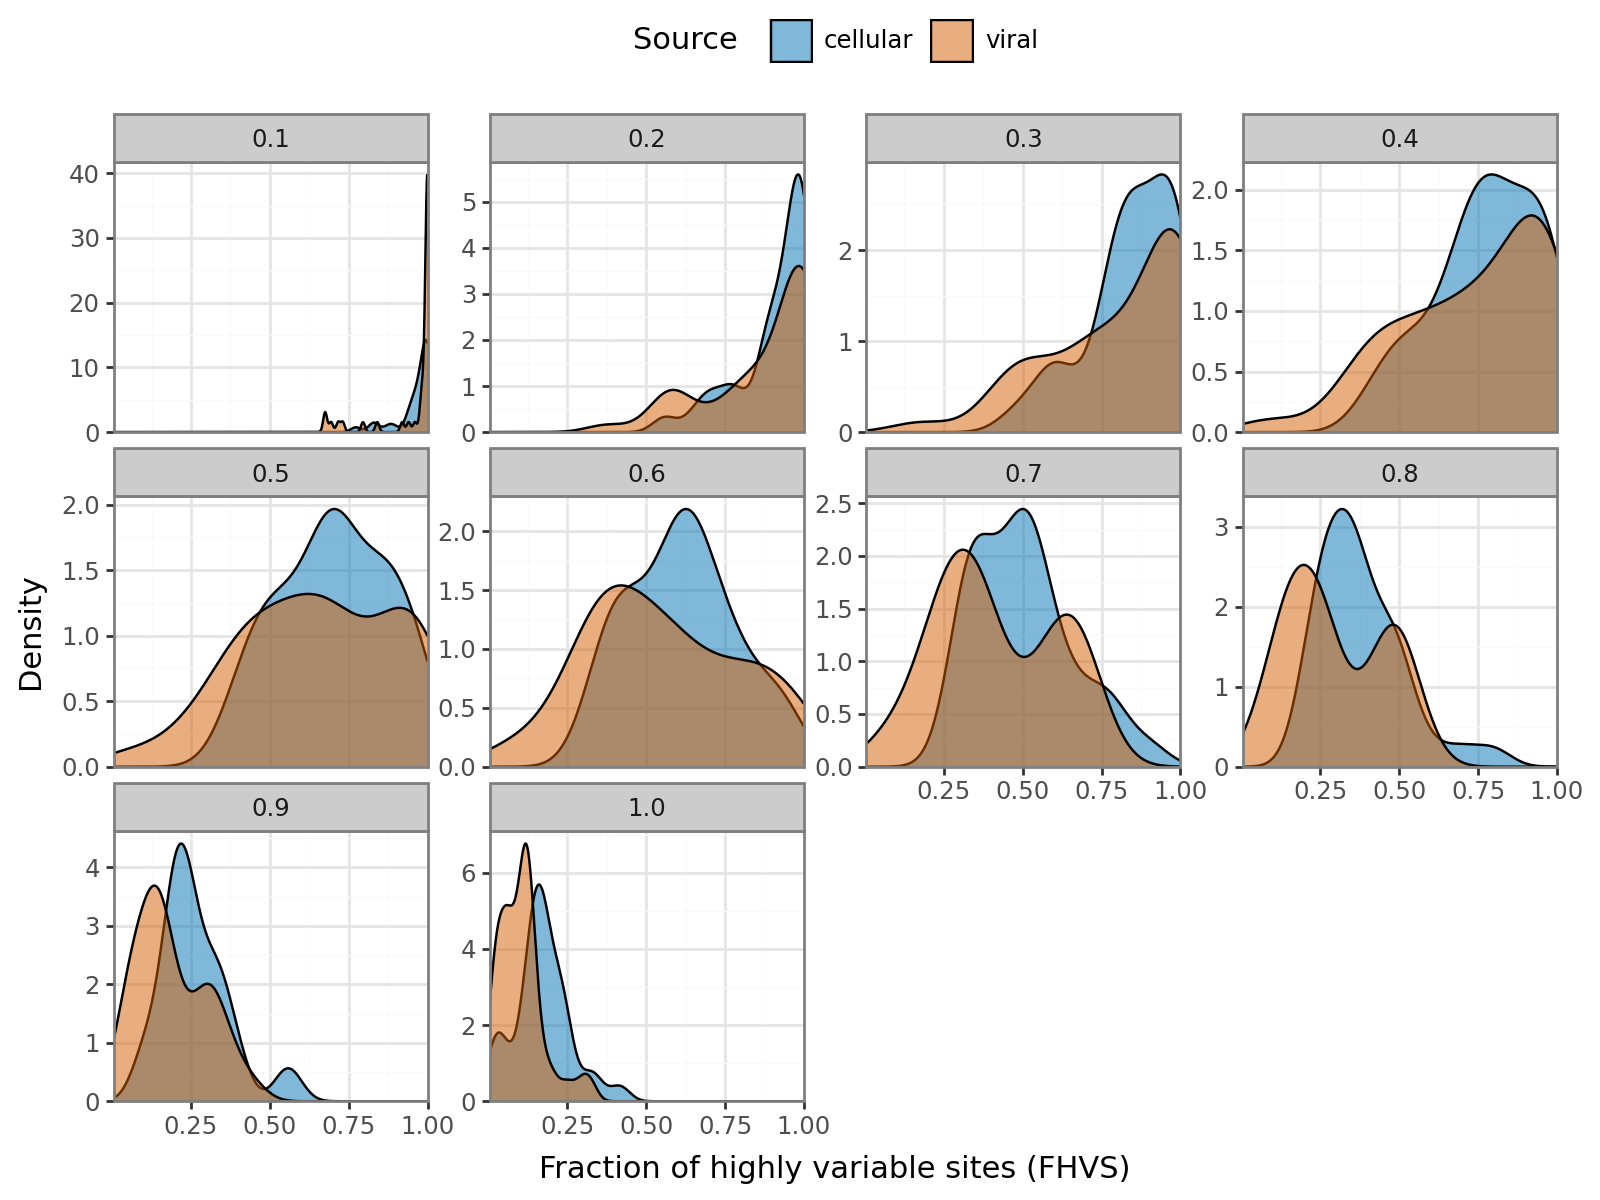

In [17]:
plot = (
    pln.ggplot(FHVS, pln.aes(x='Fraction', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_density(alpha=0.5)
    + pln.scale_y_continuous(expand = (0, 0, 0.05, 0))
    + pln.scale_x_continuous(expand = (0, 0, 0.0, 0.0))
    + pln.facet_wrap('~Treshold', scales='free_y')
    + pln.theme_bw()
    + pln.labs(
        x='Fraction of highly variable sites (FHVS)',
        y='Density',
        )
    + pln.theme(
        legend_position='top',
        figure_size=(8, 6))
    )

plot
#plot.save(filename='../experiments/FHVS/FHVS_multiple_thresholds_density.png', dpi=600)

# Filtering data by different SD thresholds

In [2]:
def read_results(res_dir_path, model_name):
    res = pd.DataFrame()
    for file in os.listdir(res_dir_path):
        if file.endswith('.csv'):
            dataset = file.split('.')[0]
            df = pd.read_csv(os.path.join(res_dir_path, file), index_col=0)
            df['Dataset'] = dataset
            res = pd.concat([res, df], ignore_index=True)
    res['Model'] = model_name
    return res

In [3]:
def load_results(lassoCV_res_dir, AVG_res_dir):
    lassoCV = pd.DataFrame()
    for model in ['esm2_650m']:
        for source in ['viral', 'cellular']:
            for method in ['pool_split']:
                res_dir_path = f'{lassoCV_res_dir}/{model}/{source}/{method}/'
                res = read_results(res_dir_path, 'ESM-2 650M')
                res['Source'] = source
                res['Split'] = method
                res['Model'] = model
                
                lassoCV = pd.concat([lassoCV, res], ignore_index=True)

    res_avg = pd.DataFrame()
    for source in ['viral', 'cellular']:
        for method in ['pool_split']:
            res_dir_path = f'{AVG_res_dir}/{source}/{method}/'
            res = read_results(res_dir_path, 'AVG')
            res['Source'] = source
            res['Split'] = method
            res_avg = pd.concat([res_avg, res], ignore_index=True)


    res = pd.concat([res_avg, lassoCV.drop('num_nonzero_coefs', axis=1)])
    res = res.groupby(['Model', 'Dataset', 'Source', 'Split'], as_index=False).mean()
    res = res.query('Split == "pool_split"')

    res_pivot = pd.pivot_table(res, index=['Dataset', 'Source', 'Split'], columns='Model', values='R2_score_test').reset_index()

    return res_pivot 

In [4]:
res_full = pd.DataFrame() 
SDs = ['SD03', 'SD05', 'SD06', 'SD08']
rn_dict = {'SD03':"SD 0.3", 'SD05':"SD 0.5", 'SD06':"SD 0.6", 'SD08':"SD 0.8"}
for sd in SDs:
    res = load_results(
        f'../experiments/FHVS/thresholds/lassoCV_{sd}_filtered',
        f'../experiments/FHVS/thresholds/AVG_{sd}_filtered/'
    )
    res['Threshold'] = rn_dict[sd]

    res_full = pd.concat([res_full, res])

res_full

Model,Dataset,Source,Split,AVG,esm2_650m,Threshold
0,AMIE_PSEAE_Whitehead,cellular,pool_split,0.298236,0.473088,SD 0.3
1,B3VI55_LIPSTSTABLE,cellular,pool_split,0.214425,0.438942,SD 0.3
2,B3VI55_LIPST_Whitehead2015,cellular,pool_split,0.148355,0.251786,SD 0.3
3,BG_STRSQ_hmmerbit,cellular,pool_split,0.000937,0.399351,SD 0.3
4,BLAT_ECOLX_Ostermeier2014,cellular,pool_split,0.448077,0.672258,SD 0.3
...,...,...,...,...,...,...
69,TPK1_HUMAN_Roth2017,cellular,pool_split,-0.059020,0.081606,SD 0.8
70,TPMT_HUMAN_Fowler2018,cellular,pool_split,0.180043,0.412859,SD 0.8
71,UBC9_HUMAN_Roth2017,cellular,pool_split,0.161364,0.279301,SD 0.8
72,UBE4B_MOUSE_Klevit2013_singles,cellular,pool_split,-0.059906,0.087061,SD 0.8


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


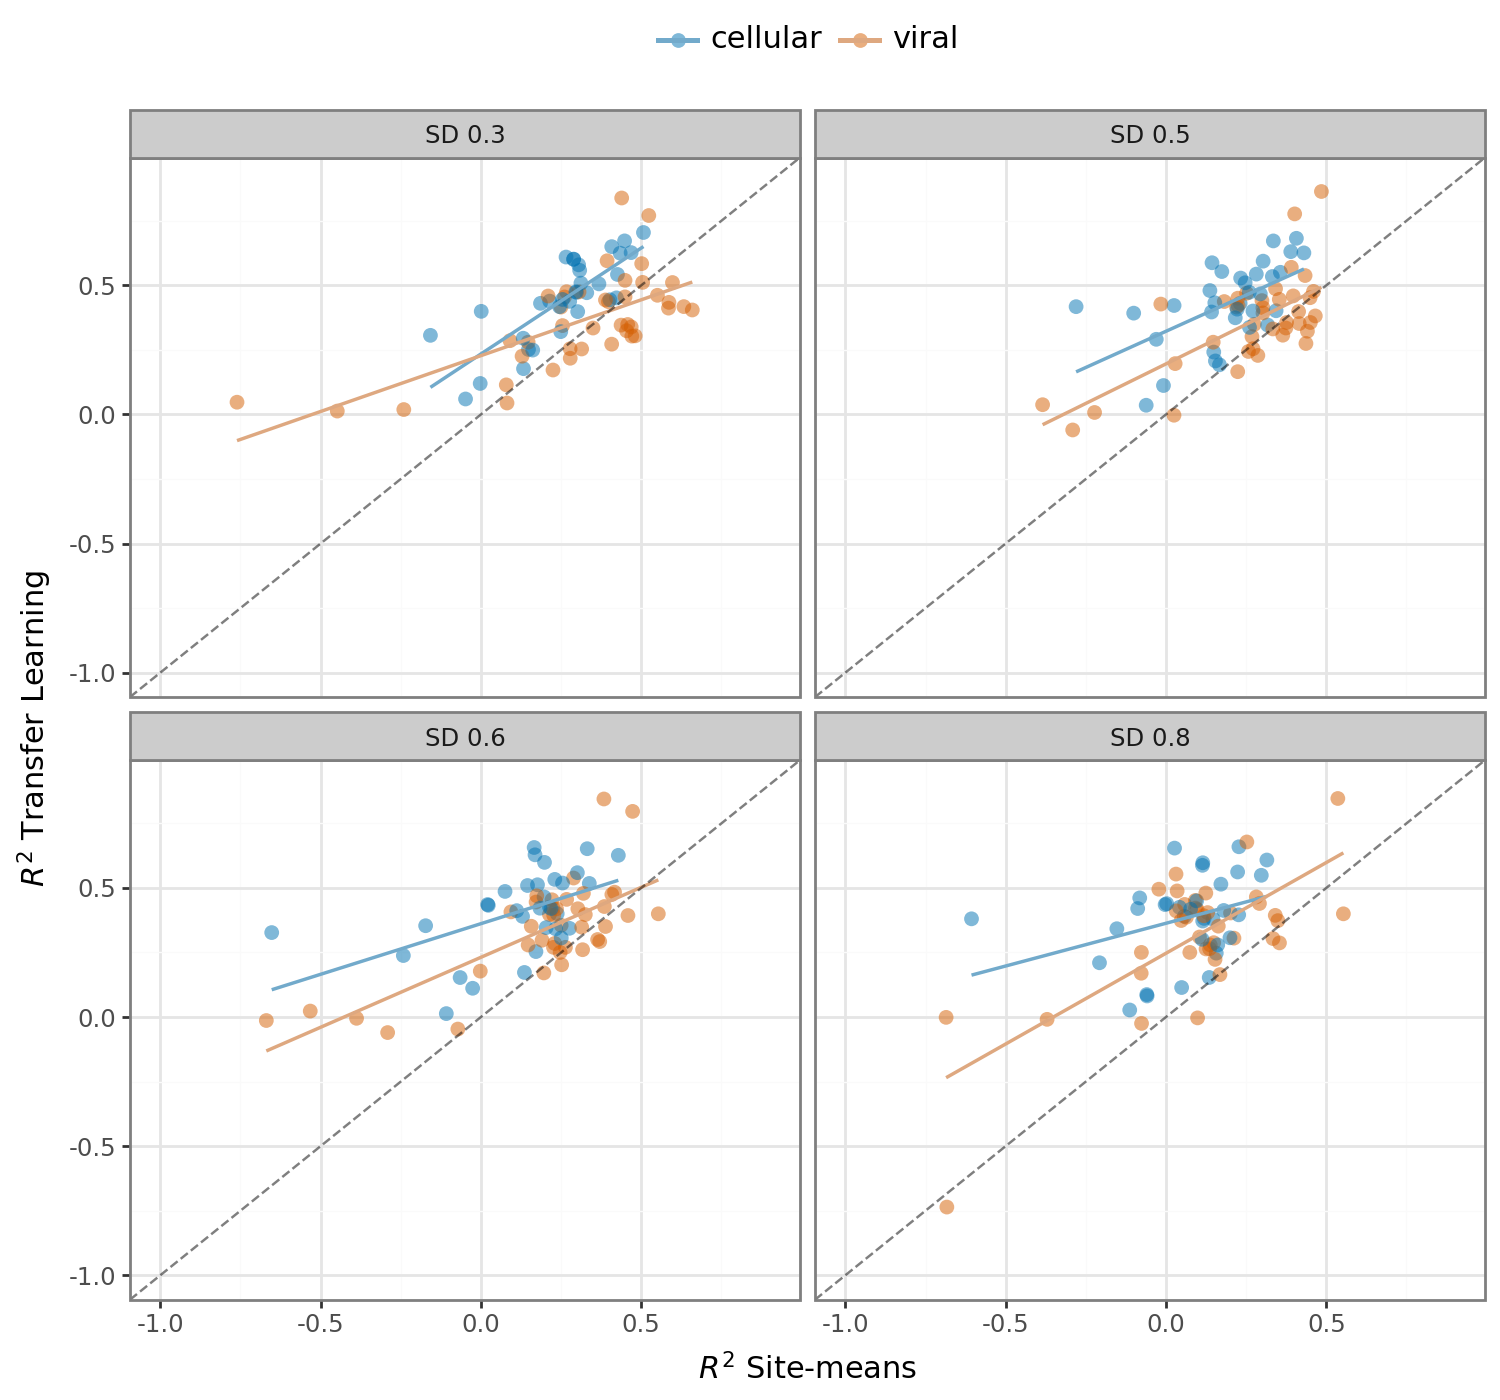

In [5]:
plot = (
        pln.ggplot(res_full, pln.aes(y='esm2_650m', x='AVG', fill='Source'))
        + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
        + pln.geom_point(size=3, alpha=0.5, stroke=0)
        + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7, mapping=pln.aes(color='Source'))
        + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
        + pln.theme_bw(11)
        + pln.geom_abline(intercept=0, alpha=0.5, linetype='dashed')
        + pln.facet_wrap('~Threshold')
        + pln.theme(
            figure_size=(7.5,7),
            legend_position='top',
            legend_text=pln.element_text(size=11),
            legend_title=pln.element_blank(),
        )
        + pln.ylim(-1, 0.9)
        + pln.xlim(-1, 0.9)
        + pln.labs(
            y="$R^2$ Transfer Learning",
            x="$R^2$ Site-means",
        )
        )

#plot.save(filename='../experiments/FHVS/FHVS_thresholds_filters.png', dpi=600)
plot